# Data Preparation

This notebook was split from the original G'Contest final-round working notebook for faster GitHub review. Raw data and data-loading code are intentionally excluded. Saved outputs are preserved so interviewers can inspect the completed analysis and results without rerunning the private dataset.

**Interview focus:** Documents the cleaning, imputation, formatting, and feature creation steps used to build the cleaned analysis dataset.


# II. Data Preparation

##**Tiền chỉnh sửa Data**

In [10]:
# Analysis step retained from the original notebook.

# Đổi tên các cột
df = df.rename(columns={
    'onboarding_status': 'status',
    'device_type': 'phone_type',
    'drop_off_point': 'stop_point',
    'cus_id': 'customer_id'
})

print("✅ Đã đổi tên các cột.")
display(df.head())

✅ Đã đổi tên các cột.


,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,02/02/2024 16:52,02/02/2024 17:55,SUCCESSFUL,F,1985.0,Apple,iOS,16.7.2,NaN,account-creation,2578
1,02/02/2024 16:33,02/02/2024 16:35,SUCCESSFUL,M,1990.0,Apple,iOS,16.1,NaN,account-creation,5181
2,02/02/2024 14:47,02/02/2024 16:55,SUCCESSFUL,F,2000.0,Apple,iOS,17.2.1,NaN,account-creation,816
3,02/02/2024 16:40,02/02/2024 16:48,SUCCESSFUL,M,1980.0,samsung,Android,12,NaN,account-creation,3562
4,02/02/2024 14:53,03/02/2024 15:24,SUCCESSFUL,F,1988.0,Apple,iOS,17.1.2,NaN,account-creation,4672


In [11]:
# Analysis step retained from the original notebook.

df['status'] = df['status'].str.lower()
print("✅ Đã chuyển đổi giá trị cột 'status' sang chữ thường.")
display(df.head())

✅ Đã chuyển đổi giá trị cột 'status' sang chữ thường.


,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,02/02/2024 16:52,02/02/2024 17:55,successful,F,1985.0,Apple,iOS,16.7.2,NaN,account-creation,2578
1,02/02/2024 16:33,02/02/2024 16:35,successful,M,1990.0,Apple,iOS,16.1,NaN,account-creation,5181
2,02/02/2024 14:47,02/02/2024 16:55,successful,F,2000.0,Apple,iOS,17.2.1,NaN,account-creation,816
3,02/02/2024 16:40,02/02/2024 16:48,successful,M,1980.0,samsung,Android,12,NaN,account-creation,3562
4,02/02/2024 14:53,03/02/2024 15:24,successful,F,1988.0,Apple,iOS,17.1.2,NaN,account-creation,4672


In [12]:
df['status'] = df['status'].replace('successful', 'succeed')
df['status'] = df['status'].replace('failed', 'fail')


In [13]:
df.head(20)

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,02/02/2024 16:52,02/02/2024 17:55,succeed,F,1985.0,Apple,iOS,16.7.2,NaN,account-creation,2578
1,02/02/2024 16:33,02/02/2024 16:35,succeed,M,1990.0,Apple,iOS,16.1,NaN,account-creation,5181
2,02/02/2024 14:47,02/02/2024 16:55,succeed,F,2000.0,Apple,iOS,17.2.1,NaN,account-creation,816
3,02/02/2024 16:40,02/02/2024 16:48,succeed,M,1980.0,samsung,Android,12,NaN,account-creation,3562
4,02/02/2024 14:53,03/02/2024 15:24,succeed,F,1988.0,Apple,iOS,17.1.2,NaN,account-creation,4672
5,28/02/2024 15:29,28/02/2024 15:32,succeed,M,1997.0,Apple,iOS,17.3.1,NaN,account-creation,3255
6,28/02/2024 15:23,28/02/2024 15:27,succeed,F,1978.0,samsung,Android,12,NaN,account-creation,2800
7,28/02/2024 15:21,28/02/2024 15:24,succeed,M,1989.0,samsung,Android,14,NaN,account-creation,4195
8,29/02/2024 13:38,29/02/2024 13:42,succeed,F,1992.0,Apple,iOS,17.3.1,NaN,account-creation,331
9,29/02/2024 13:32,29/02/2024 13:34,succeed,F,1999.0,Apple,iOS,17.3.1,NaN,account-creation,1585


In [14]:
df.phone_type.value_counts

<bound method IndexOpsMixin.value_counts of 0          Apple
1          Apple
2          Apple
3        samsung
4          Apple
          ...   
25741       vivo
25742    samsung
25743      Apple
25744       OPPO
25745      Apple
Name: phone_type, Length: 25746, dtype: object>

## 1. Fill Missing Values by Consistent Customer ID

In [15]:
# Analysis step retained from the original notebook.

df_sorted = df.sort_values(by=['customer_id', 'begin_time']).reset_index(drop=True)
df_sorted.head()

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,01/03/2024 10:32,01/03/2024 10:32,pending,NaN,NaN,Apple,iOS,16.1.1,NaN,otp-failed,0
1,01/03/2024 19:38,01/03/2024 19:41,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0
2,01/03/2024 10:25,01/03/2024 10:25,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
3,01/03/2024 16:16,01/03/2024 16:17,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
4,04/03/2024 13:30,04/03/2024 13:31,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1


In [16]:
# Analysis step retained from the original notebook.

columns_to_fill = ['gender', 'birth_year', 'phone_type']
for col in columns_to_fill:
  # Check if there are inconsistent values for the same customer_id
  inconsistent_customers = df_sorted.groupby('customer_id')[col].nunique()
  inconsistent_customers = inconsistent_customers[inconsistent_customers > 1].index.tolist()

  if inconsistent_customers:
    print(f"Warning: Inconsistent values found for column '{col}' for the following customer_ids: {inconsistent_customers}")
    # You might want to add logic here to decide how to handle inconsistencies,
    # e.g., pick the most frequent value, or fill with a specific value.
    # For now, we'll proceed with filling based on the first non-null value
    # encountered for each customer_id during the forward fill.

  # Fill null values within each customer_id group
  df_sorted[col] = df_sorted.groupby('customer_id')[col].fillna(method='ffill')
  df_sorted[col] = df_sorted.groupby('customer_id')[col].fillna(method='bfill')

print("\nDataFrame after filling nulls:")
print(df_sorted.head())
print("\nNull counts after filling:")
print(df_sorted[columns_to_fill].isna().sum())

/tmp/ipykernel_366/3078988111.py:17: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  df_sorted[col] = df_sorted.groupby('customer_id')[col].fillna(method='ffill')
/tmp/ipykernel_366/3078988111.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_sorted[col] = df_sorted.groupby('customer_id')[col].fillna(method='ffill')
/tmp/ipykernel_366/3078988111.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_sorted[col] = df_sorted.groupby('customer_id')[col].fillna(method='ffill')
/tmp/ipykernel_366/307


DataFrame after filling nulls:
         begin_time        close_time   status gender  birth_year phone_type  \
0  01/03/2024 10:32  01/03/2024 10:32  pending      F      1993.0      Apple   
1  01/03/2024 19:38  01/03/2024 19:41  succeed      F      1993.0      Apple   
2  01/03/2024 10:25  01/03/2024 10:25     fail      F      1998.0      Apple   
3  01/03/2024 16:16  01/03/2024 16:17     fail      F      1998.0      Apple   
4  04/03/2024 13:30  04/03/2024 13:31     fail      F      1998.0      Apple   

  device_system_name os_version      rejected_reason        stop_point  \
0                iOS     16.1.1                  NaN        otp-failed   
1                iOS     16.1.1                  NaN  account-creation   
2                iOS       15.6  document-ocr-failed        ocr-failed   
3                iOS       15.6  document-ocr-failed        ocr-failed   
4                iOS       15.6  document-ocr-failed        ocr-failed   

   customer_id  
0            0  
1       

In [17]:
#Check các cột vẫn còn null
# Cột cần kiểm tra
columns_to_check = ['gender', 'birth_year', 'phone_type']

# Lọc ra những dòng còn thiếu giá trị ở ít nhất một trong các cột trên
unfilled_rows = df_sorted[df_sorted[columns_to_check].isna().any(axis=1)]

# Hiển thị kết quả
print("\n📌 Các dòng vẫn còn chứa null sau khi fill:")
unfilled_rows

# Nếu muốn xuất ra file CSV để kiểm tra



📌 Các dòng vẫn còn chứa null sau khi fill:


,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
15,29/01/2024 14:48,29/01/2024 14:48,pending,M,1992.0,NaN,NaN,NaN,NaN,data-privacy-rejected,4
16,29/01/2024 14:53,29/01/2024 14:53,pending,M,1992.0,NaN,NaN,NaN,NaN,otp-failed,4
17,29/01/2024 14:55,29/01/2024 14:57,succeed,M,1992.0,NaN,NaN,NaN,NaN,account-creation,4
20,23/03/2024 11:32,23/03/2024 11:32,pending,NaN,NaN,Apple,iOS,16.3.1,NaN,data-privacy-rejected,6
21,27/03/2024 07:26,27/03/2024 07:26,pending,NaN,NaN,Apple,iOS,16.3.1,NaN,data-privacy-rejected,6
...,...,...,...,...,...,...,...,...,...,...,...
25589,02/02/2024 15:28,02/02/2024 15:28,fail,M,1997.0,NaN,NaN,NaN,NaN,check-failed,9100
25651,28/01/2024 22:27,28/01/2024 22:27,pending,F,1994.0,NaN,NaN,NaN,NaN,otp-failed,9116
25652,28/01/2024 22:28,28/01/2024 22:29,succeed,F,1994.0,NaN,NaN,NaN,NaN,account-creation,9116
25692,29/02/2024 13:53,29/02/2024 13:54,pending,NaN,NaN,Apple,iOS,16.3.1,NaN,otp-failed,9130


## 2. Context-Based Imputation

In [18]:
df_context = df_sorted.copy()

In [19]:
# Tính phân phối giới tính theo phone_type
gender_dist = df_context.groupby('phone_type')['gender'].value_counts(normalize=True).unstack()
print(gender_dist)


gender             F         M
phone_type                    
Apple       0.601030  0.398970
HONOR            NaN  1.000000
HUAWEI      0.361702  0.638298
Infinix     1.000000       NaN
KDDI             NaN  1.000000
Nokia       0.285714  0.714286
OPPO        0.531250  0.468750
OnePlus     0.615385  0.384615
POCO        0.377778  0.622222
Redmi       0.427966  0.572034
SG               NaN  1.000000
Sony        0.160000  0.840000
TECNO            NaN  1.000000
Unihertz         NaN  1.000000
Xiaomi      0.386364  0.613636
asus             NaN  1.000000
blackberry       NaN  1.000000
google      0.173077  0.826923
lge         0.888889  0.111111
realme      0.365854  0.634146
samsung     0.471520  0.528480
vivo        0.522124  0.477876
vsmart      0.310345  0.689655
xiaomi      0.692308  0.307692


In [20]:
import pandas as pd
import numpy as np

# 👉 Trước khi fill: đếm số dòng có gender bị thiếu
missing_before = df_context['gender'].isna().sum()
print(f"Số dòng thiếu gender trước khi fill: {missing_before}")

# Bước 1: Tính phân phối giới tính theo phone_type
gender_dist = (
    df_context.groupby('phone_type')['gender']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

# Bước 2: Lấy các phone_type có 1 giới tính chiếm > 60%
dominant_gender_map = {}

for phone_type, row in gender_dist.iterrows():
    for gender in ['F', 'M']:
        if row.get(gender, 0) > 0.6:
            dominant_gender_map[phone_type] = gender
            break  # Ưu tiên giới tính đầu tiên đủ điều kiện

# Bước 3: Fill gender nếu thiếu và phone_type phù hợp
def fill_gender(row):
    if pd.isna(row['gender']) and row['phone_type'] in dominant_gender_map:
        return dominant_gender_map[row['phone_type']]
    return row['gender']

df_context['gender'] = df_context.apply(fill_gender, axis=1)

# 👉 Sau khi fill: đếm số dòng còn thiếu
missing_after = df_context['gender'].isna().sum()
print(f"Số dòng thiếu gender sau khi fill: {missing_after}")


Số dòng thiếu gender trước khi fill: 780
Số dòng thiếu gender sau khi fill: 231


In [21]:
import pandas as pd

# Bước 1: Tạo cột tuổi và nhóm tuổi nếu chưa có
df_context['age'] = 2024 - df_context['birth_year']
age_bins = [0, 18, 25, 35, 45, 60, 120]
age_labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']
df_context['age_group'] = pd.cut(df_context['age'], bins=age_bins, labels=age_labels, right=False)

# Bước 2: Tính phân phối nhóm tuổi theo phone_type
agegroup_dist = (
    df_context.groupby('phone_type')['age_group']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0)
)

# Hiển thị kết quả
print("\n📊 Phân phối nhóm tuổi theo từng phone_type (%):")
print((agegroup_dist * 100).round(2))



📊 Phân phối nhóm tuổi theo từng phone_type (%):
age_group   <18  18-25   26-35   36-45   46-60    60+
phone_type                                           
Apple       0.0   6.80   59.77   28.29    4.81   0.33
HONOR       0.0   0.00  100.00    0.00    0.00   0.00
HUAWEI      0.0   0.00   25.53   74.47    0.00   0.00
Infinix     0.0   0.00  100.00    0.00    0.00   0.00
KDDI        0.0   0.00  100.00    0.00    0.00   0.00
Nokia       0.0  33.33   14.29   28.57   23.81   0.00
OPPO        0.0   3.69   43.75   44.60    7.95   0.00
OnePlus     0.0   0.00  100.00    0.00    0.00   0.00
POCO        0.0   6.67   51.11   40.00    2.22   0.00
Redmi       0.0   3.18   39.19   45.13    2.75   9.75
SG          0.0   0.00    0.00  100.00    0.00   0.00
Sony        0.0   0.00   56.00   44.00    0.00   0.00
TECNO       0.0   4.55   93.94    1.52    0.00   0.00
Unihertz    0.0   0.00    0.00    0.00  100.00   0.00
Xiaomi      0.0   1.82   60.91   19.09    1.82  16.36
asus        0.0   0.00  100.00   

In [22]:
# Tìm tất cả phone_type có 1 nhóm tuổi chiếm > 60%
dominant_age_group_map = {}

for phone_type, row in agegroup_dist.iterrows():
    for age_group, ratio in row.items():
        if ratio > 0.4:
            dominant_age_group_map[phone_type] = age_group
            break  # Ưu tiên nhóm tuổi đầu tiên đủ điều kiện
# Mapping nhóm tuổi → birth_year trung bình (làm tròn ngược lại)
age_group_mean_year = {
    '<18': 2024 - 15,
    '18-25': 2024 - 22,
    '26-35': 2024 - 30,
    '36-45': 2024 - 40,
    '46-60': 2024 - 52,
    '60+': 2024 - 65,
}

# Hàm fill birth_year nếu thiếu
def fill_birth_year_by_age_group(row):
    if pd.isna(row['birth_year']) and row['phone_type'] in dominant_age_group_map:
        group = dominant_age_group_map[row['phone_type']]
        return age_group_mean_year.get(group, np.nan)
    return row['birth_year']

# Áp dụng fill
df_context['birth_year'] = df_context.apply(fill_birth_year_by_age_group, axis=1)

# In số dòng còn thiếu sau khi fill
print("Số dòng thiếu birth_year sau khi fill theo age_group dominant:", df_context['birth_year'].isna().sum())


Số dòng thiếu birth_year sau khi fill theo age_group dominant: 68


In [23]:
import pandas as pd

# Bước 1: Tính tuổi và gán nhóm tuổi
df_context['age'] = 2024 - df_context['birth_year']
age_bins = [0, 18, 25, 35, 45, 60, 120]
age_labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']
df_context['age_group'] = pd.cut(df_context['age'], bins=age_bins, labels=age_labels, right=False)

# Bước 2: Tính tỷ lệ xuất hiện phone_type theo gender + age_group
combo = (
    df_context.groupby(['gender', 'age_group'], observed=True)['phone_type']
    .value_counts(normalize=True)
    .rename("ratio")
    .reset_index()
)

# Bước 3: Lấy top 3 phone_type phổ biến nhất trong từng nhóm
top3 = (
    combo.groupby(['gender', 'age_group'], observed=True)
    .apply(lambda x: x.nlargest(3, columns='ratio', keep='all'))
    .reset_index(drop=True)
)

# Bước 4: Định dạng tỷ lệ %
top3['ratio'] = (top3['ratio'] * 100).round(2).astype(str) + '%'

# Hiển thị kết quả
print("\n📊 Top 3 phone_type theo từng nhóm gender + độ tuổi:")
print(top3)



📊 Top 3 phone_type theo từng nhóm gender + độ tuổi:
   gender age_group phone_type   ratio
0       F     18-25      Apple  89.98%
1       F     18-25    samsung   6.65%
2       F     18-25       OPPO   1.23%
3       F     26-35      Apple  89.01%
4       F     26-35    samsung   7.25%
5       F     26-35       OPPO   1.12%
6       F     36-45      Apple  71.31%
7       F     36-45    samsung  20.38%
8       F     36-45      Redmi   2.73%
9       F     46-60      Apple  70.78%
10      F     46-60    samsung  22.17%
11      F     46-60     vsmart   2.52%
12      F       60+      Apple  44.44%
13      F       60+    samsung  33.33%
14      F       60+      Redmi  22.22%
15      M     18-25      Apple  82.95%
16      M     18-25     vsmart   5.94%
17      M     18-25    samsung   4.65%
18      M     26-35      Apple  77.95%
19      M     26-35    samsung  12.75%
20      M     26-35      Redmi   2.08%
21      M     36-45      Apple  67.49%
22      M     36-45    samsung  22.97%
23      M  

/tmp/ipykernel_366/2533564212.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, columns='ratio', keep='all'))


In [24]:
import pandas as pd
import numpy as np

# 👉 Bước 0: Số dòng thiếu trước khi fill
missing_before = df_context['phone_type'].isna().sum()
print(f"Số dòng thiếu phone_type trước khi fill: {missing_before}")

# Bước 1: Chuyển 'ratio' từ chuỗi thành float
top3['ratio_float'] = top3['ratio'].str.rstrip('%').astype(float)

# Bước 2: Tạo dict mapping từ (gender, age_group) → phone_type nếu tỉ lệ > 60%
combo_to_phone = {
    (row['gender'], row['age_group']): row['phone_type']
    for _, row in top3.iterrows()
    if row['ratio_float'] > 60
}

# Bước 3: Hàm fill phone_type nếu thiếu và có combo phù hợp
def fill_phone_type(row):
    key = (row['gender'], row['age_group'])
    if pd.isna(row['phone_type']) and key in combo_to_phone:
        return combo_to_phone[key]
    return row['phone_type']

# Bước 4: Áp dụng fill
df_context['phone_type'] = df_context.apply(fill_phone_type, axis=1)

# 👉 Bước 5: Số dòng thiếu sau khi fill
missing_after = df_context['phone_type'].isna().sum()
print(f"Số dòng thiếu phone_type sau khi fill: {missing_after}")


Số dòng thiếu phone_type trước khi fill: 2384
Số dòng thiếu phone_type sau khi fill: 35


In [25]:
# Analysis step retained from the original notebook.

df_context = df_context.drop(columns=['age_group'])

In [26]:
# Đếm số dòng thiếu ở cả 3 cột cùng lúc
missing_all_three = df_context[
    df_context[['gender', 'birth_year', 'phone_type']].isna().all(axis=1)
]

print(f"Số dòng thiếu ở cả 3 cột (gender, birth_year, phone_type): {len(missing_all_three)}")


Số dòng thiếu ở cả 3 cột (gender, birth_year, phone_type): 35


##**3. Fill phần còn lại bằng Forward/Backward Fill**

In [27]:
# 👉 Bước 1: Số dòng thiếu trước khi fill
nulls_before = df_context[['gender', 'birth_year', 'phone_type']].isna().sum()
print("Số dòng thiếu trước khi forward fill:")
print(nulls_before)

# 👉 Bước 2: Fill toàn bảng (không theo group)
for col in ['gender', 'birth_year', 'phone_type']:
    df_context[col] = df_context[col].ffill().bfill()

# 👉 Bước 3: Số dòng thiếu sau khi fill
nulls_after = df_context[['gender', 'birth_year', 'phone_type']].isna().sum()
print("\nSố dòng thiếu sau khi forward + backward fill:")
print(nulls_after)


Số dòng thiếu trước khi forward fill:
gender        231
birth_year     68
phone_type     35
dtype: int64

Số dòng thiếu sau khi forward + backward fill:
gender        0
birth_year    0
phone_type    0
dtype: int64


### **Check lại sau khi fill null**

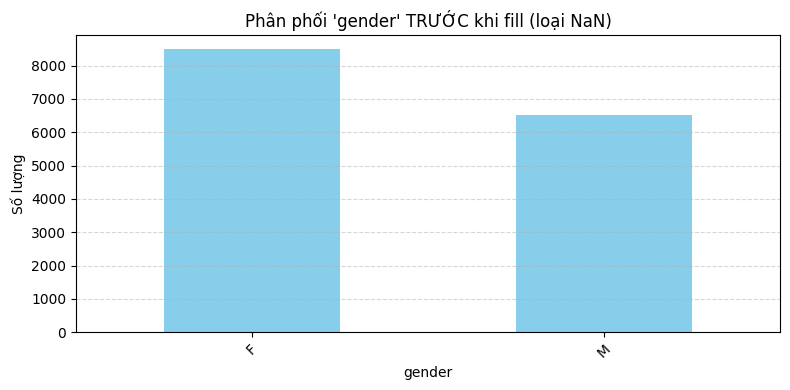

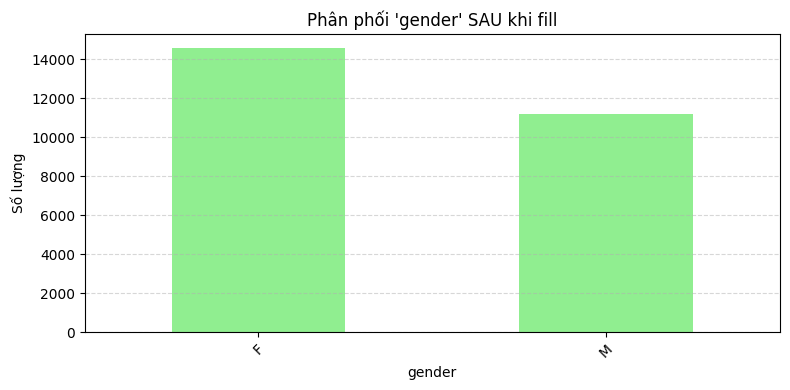

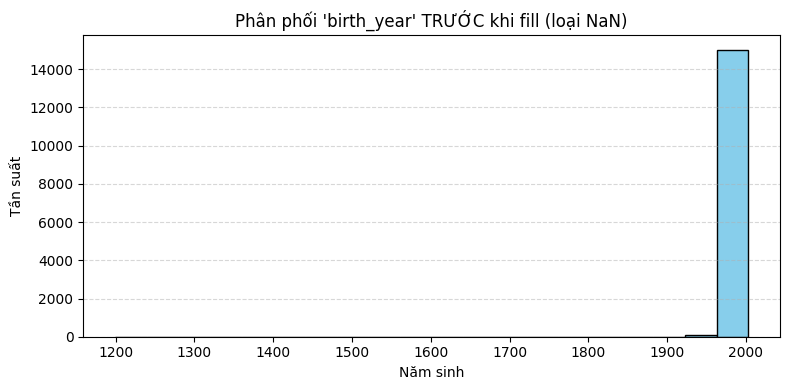

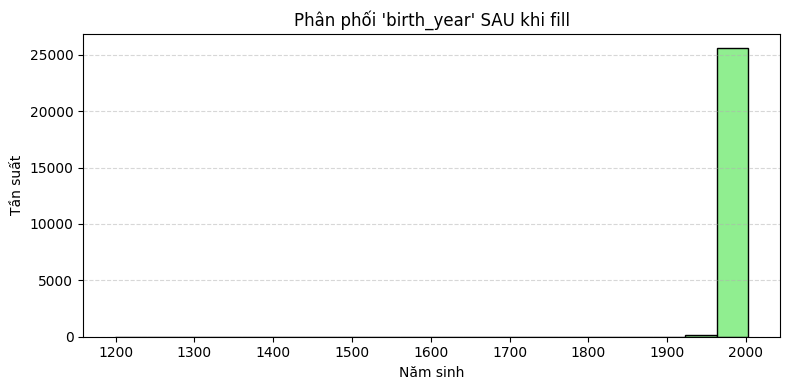

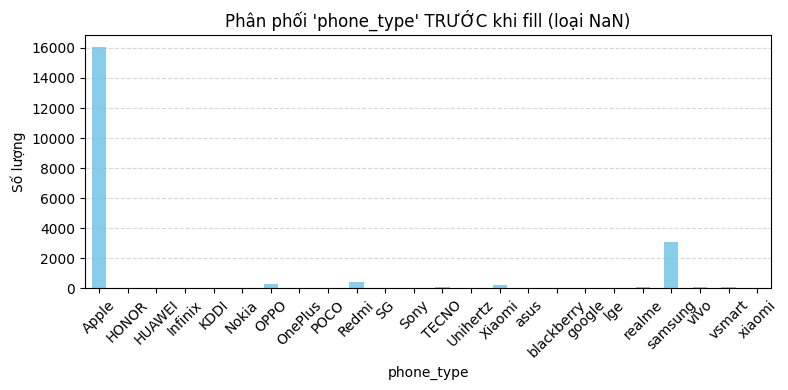

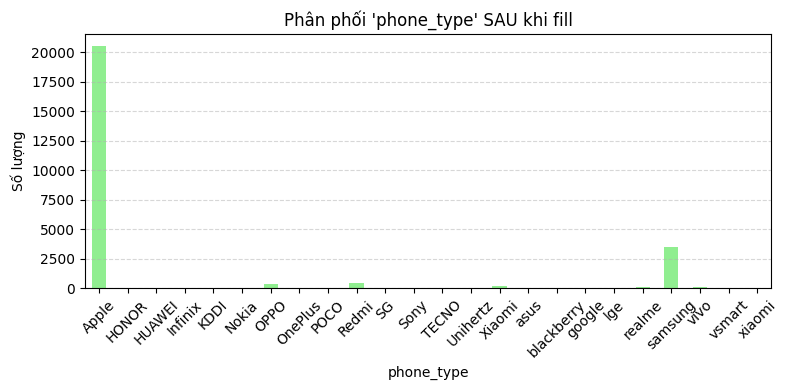

In [28]:
import matplotlib.pyplot as plt

cols_to_plot = ['gender', 'birth_year', 'phone_type']

for col in cols_to_plot:
    if col == 'birth_year':
        # 🟦 Histogram TRƯỚC khi fill (loại NaN)
        before_vals = df[col].dropna()
        plt.figure(figsize=(8, 4))
        plt.hist(before_vals, bins=20, color='skyblue', edgecolor='black')
        plt.title("Phân phối 'birth_year' TRƯỚC khi fill (loại NaN)")
        plt.xlabel("Năm sinh")
        plt.ylabel("Tần suất")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        # 🟩 Histogram SAU khi fill
        after_vals = df_context[col].dropna()
        plt.figure(figsize=(8, 4))
        plt.hist(after_vals, bins=20, color='lightgreen', edgecolor='black')
        plt.title("Phân phối 'birth_year' SAU khi fill")
        plt.xlabel("Năm sinh")
        plt.ylabel("Tần suất")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

    else:
        # Biểu đồ cột cho gender và phone_type
        before_dist = df[col].dropna().value_counts().sort_index()
        plt.figure(figsize=(8, 4))
        before_dist.plot(kind='bar', color='skyblue')
        plt.title(f"Phân phối '{col}' TRƯỚC khi fill (loại NaN)")
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

        after_dist = df_context[col].value_counts(dropna=False).sort_index()
        plt.figure(figsize=(8, 4))
        after_dist.plot(kind='bar', color='lightgreen')
        plt.title(f"Phân phối '{col}' SAU khi fill")
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plt.xticks(rotation=45)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()


In [29]:
df_context.isna().sum()

,0
begin_time,0
close_time,0
status,0
gender,0
birth_year,0
phone_type,0
device_system_name,5081
os_version,5081
rejected_reason,22679
stop_point,0


In [30]:
# Analysis step retained from the original notebook.

df_context = df_context.drop(columns=['age'])

## **4. FIll null những cột mới**

## Data Input Note

Raw data reading code is excluded from the public notebook. This section keeps the analysis narrative and saved outputs for review.


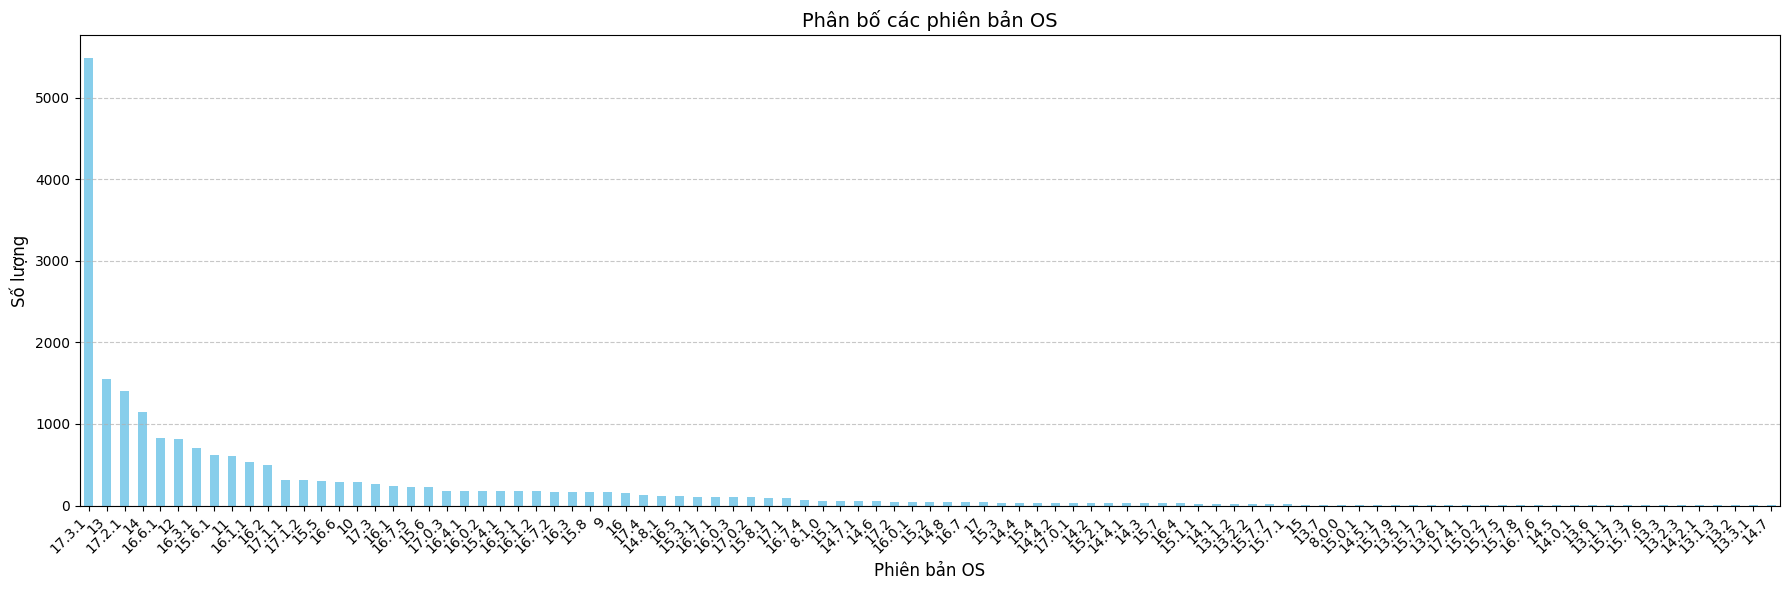

In [32]:
# Analysis step retained from the original notebook.

# Đếm số lượng mỗi phiên bản OS
os_version_counts = df['os_version'].value_counts()

# Tạo bar chart
plt.figure(figsize=(18, 6))
os_version_counts.plot(kind='bar', color='skyblue')
plt.title('Phân bố các phiên bản OS', fontsize=14)
plt.xlabel('Phiên bản OS', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.xticks(rotation=45, ha='right') # Xoay nhãn trục x cho dễ đọc
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Điều chỉnh layout để tránh cắt xén
plt.show()

In [33]:



# Tính mode theo từng nhóm
mode_table = (
    df_context.dropna(subset=['os_version'])  # Bỏ các dòng có os_version bị thiếu
    .groupby(['phone_type', 'device_system_name'])['os_version']
    .agg(lambda x: x.mode().tolist())  # Lấy danh sách mode (có thể nhiều hơn 1 giá trị)
    .reset_index()
    .rename(columns={'os_version': 'os_version_mode'})
)

# In kết quả
print(mode_table)

    phone_type device_system_name os_version_mode
0        Apple                iOS        [17.3.1]
1        Apple             iPadOS        [17.3.1]
2        HONOR            Android            [14]
3       HUAWEI            Android             [9]
4      Infinix            Android            [12]
5         KDDI            Android            [12]
6        Nokia            Android            [13]
7         OPPO            Android            [13]
8      OnePlus            Android            [14]
9         POCO            Android            [13]
10       Redmi            Android            [13]
11          SG            Android            [12]
12        Sony            Android            [14]
13       TECNO            Android            [13]
14    Unihertz            Android            [11]
15      Xiaomi            Android            [13]
16        asus            Android            [13]
17  blackberry            Android         [8.1.0]
18      google            Android            [14]


In [34]:
# Tính mode của os_version theo groupby phone_type và device_system_name
mode_per_group = (
    df_context.groupby(['phone_type', 'device_system_name'])['os_version']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index()
    .rename(columns={'os_version': 'os_version_mode'})
)

# Gộp giá trị mode vào df_context
df_context = df_context.merge(mode_per_group, on=['phone_type', 'device_system_name'], how='left')

# Điền các giá trị null trong os_version bằng mode của nhóm
df_context['os_version'] = df_context['os_version'].fillna(df_context['os_version_mode'])

# Loại bỏ cột phụ sau khi đã fill xong
df_context.drop(columns=['os_version_mode'], inplace=True)


In [35]:
# Check remaining missing values after imputation.

df_context.isna().sum()

,0
begin_time,0
close_time,0
status,0
gender,0
birth_year,0
phone_type,0
device_system_name,0
os_version,0
rejected_reason,22679
stop_point,0


In [36]:
df.stop_point.value_counts()

,count
stop_point,
account-creation,8543
otp-failed,5612
ocr-failed,5404
data-privacy-rejected,2398
contract-rejected,1785
check-failed,1632
selfie-failed,372


In [37]:
# Tạo bảng đếm số lần xuất hiện rejected_reason theo từng stop_point
rejected_table = pd.crosstab(df_context['stop_point'], df_context['rejected_reason'])

# Hiển thị bảng
rejected_table


rejected_reason,aml-warning,contract-rejected,contract_rejected,document-check-declined,document-ocr-failed,face-deduplicated,face-matching-low,fatca,id-deduplicated,liveness-low,otp-check-failed,selfie-check-declined
stop_point,,,,,,,,,,,,
check-failed,13,0,0,83,0,0,0,15,6,0,0,0
contract-rejected,0,10,1,68,0,0,0,0,0,0,0,0
ocr-failed,0,0,0,0,2622,0,0,0,0,0,0,0
otp-failed,0,0,0,0,0,0,0,0,1,0,45,0
selfie-failed,0,0,0,0,0,2,28,0,0,97,0,76


In [38]:
df_context

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,01/03/2024 10:32,01/03/2024 10:32,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0
1,01/03/2024 19:38,01/03/2024 19:41,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0
2,01/03/2024 10:25,01/03/2024 10:25,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
3,01/03/2024 16:16,01/03/2024 16:17,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
4,04/03/2024 13:30,04/03/2024 13:31,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
...,...,...,...,...,...,...,...,...,...,...,...
25741,29/02/2024 14:20,29/02/2024 14:23,succeed,F,1990.0,Apple,iOS,16.4.1,NaN,account-creation,9146
25742,01/03/2024 15:29,01/03/2024 15:30,fail,M,1984.0,Apple,iOS,17.3.1,document-ocr-failed,ocr-failed,9147
25743,01/03/2024 15:31,01/03/2024 15:31,pending,M,1984.0,Apple,iOS,17.3.1,NaN,otp-failed,9147
25744,01/03/2024 15:32,01/03/2024 15:36,succeed,M,1984.0,Apple,iOS,17.3.1,NaN,account-creation,9147


###Check lại sau khi fill null

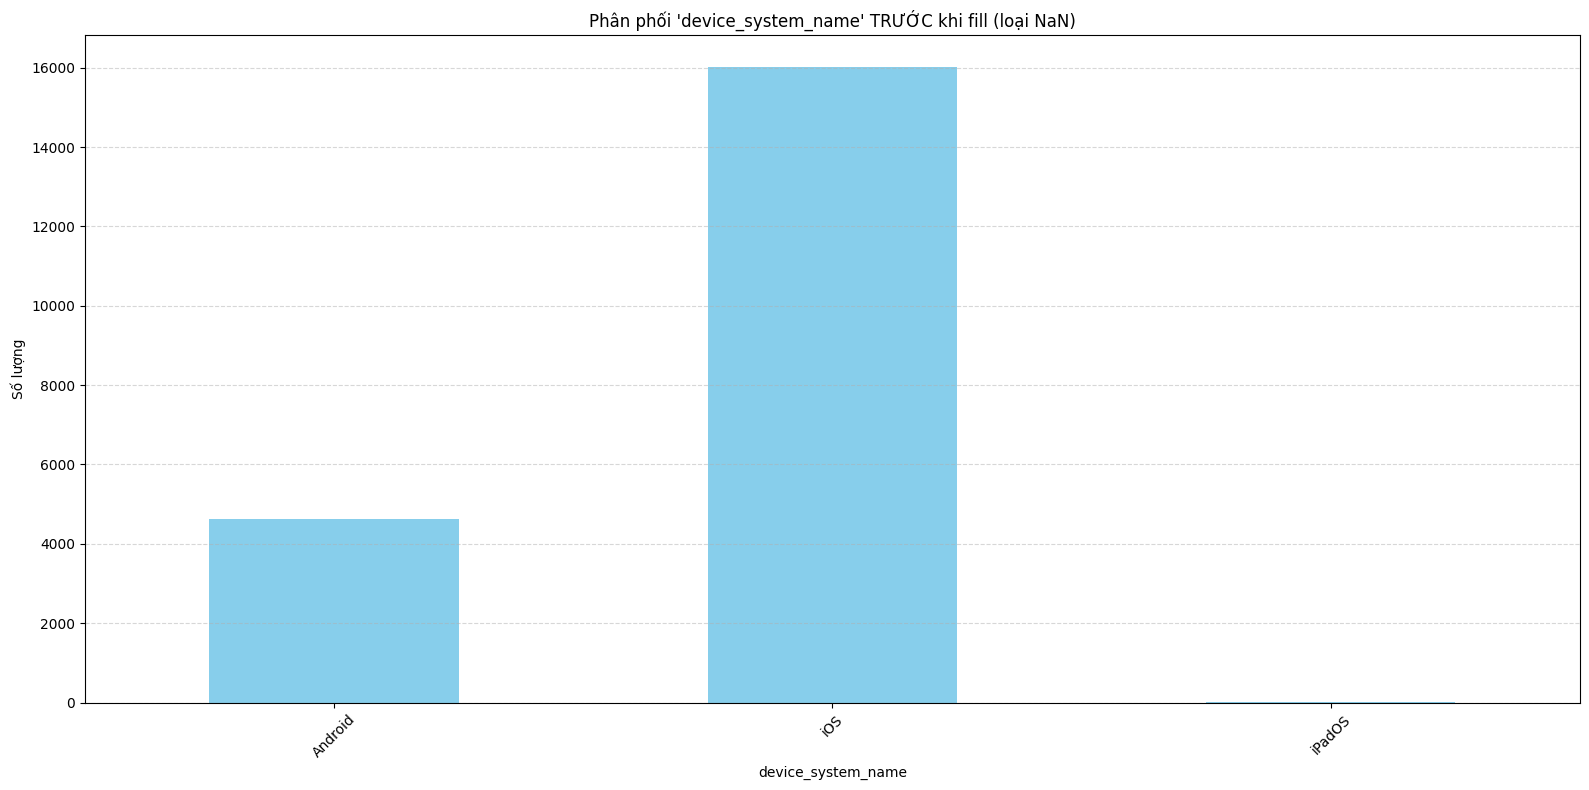

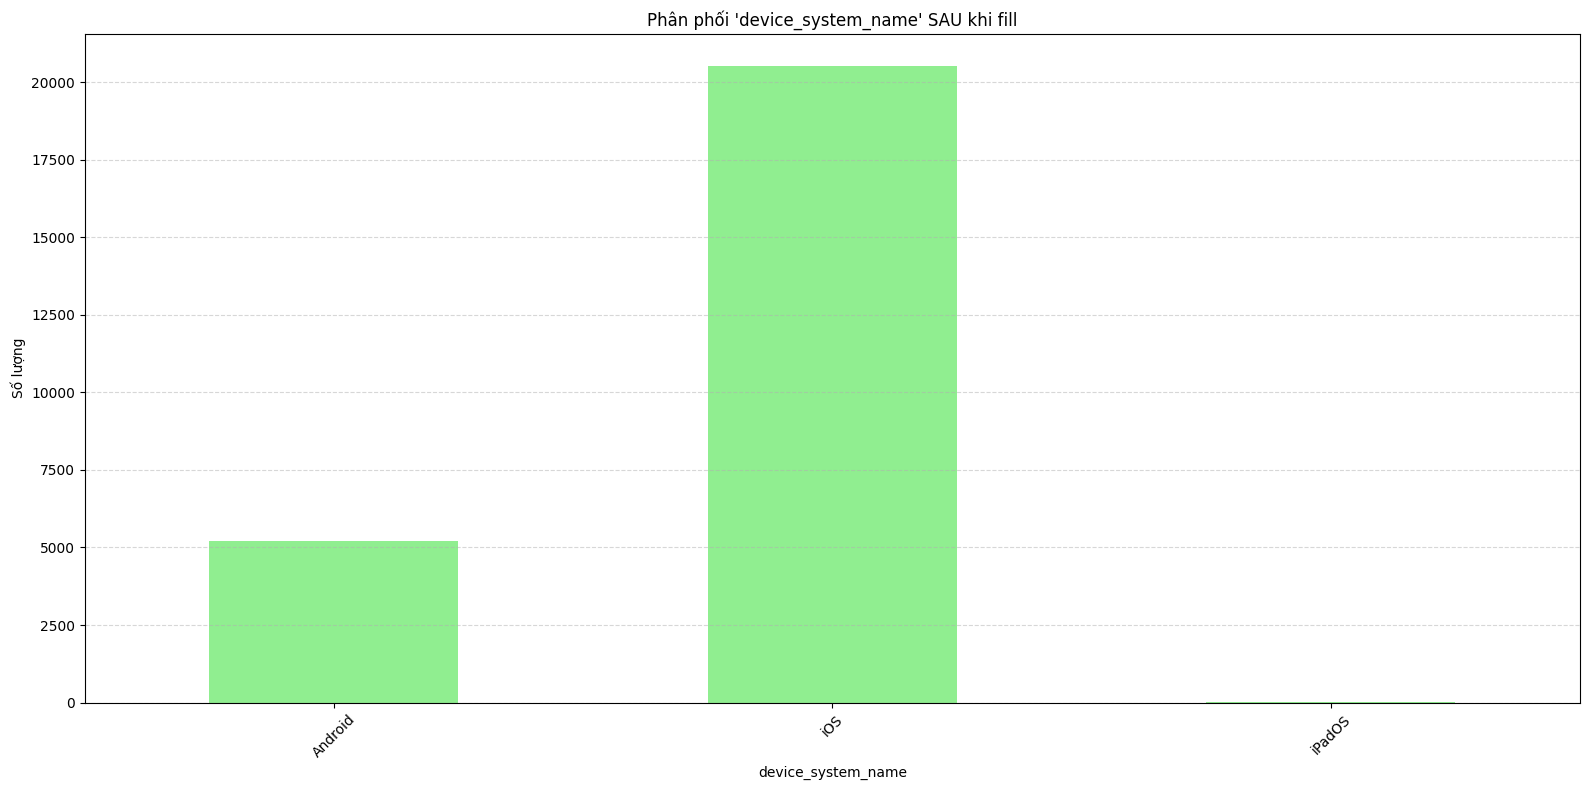

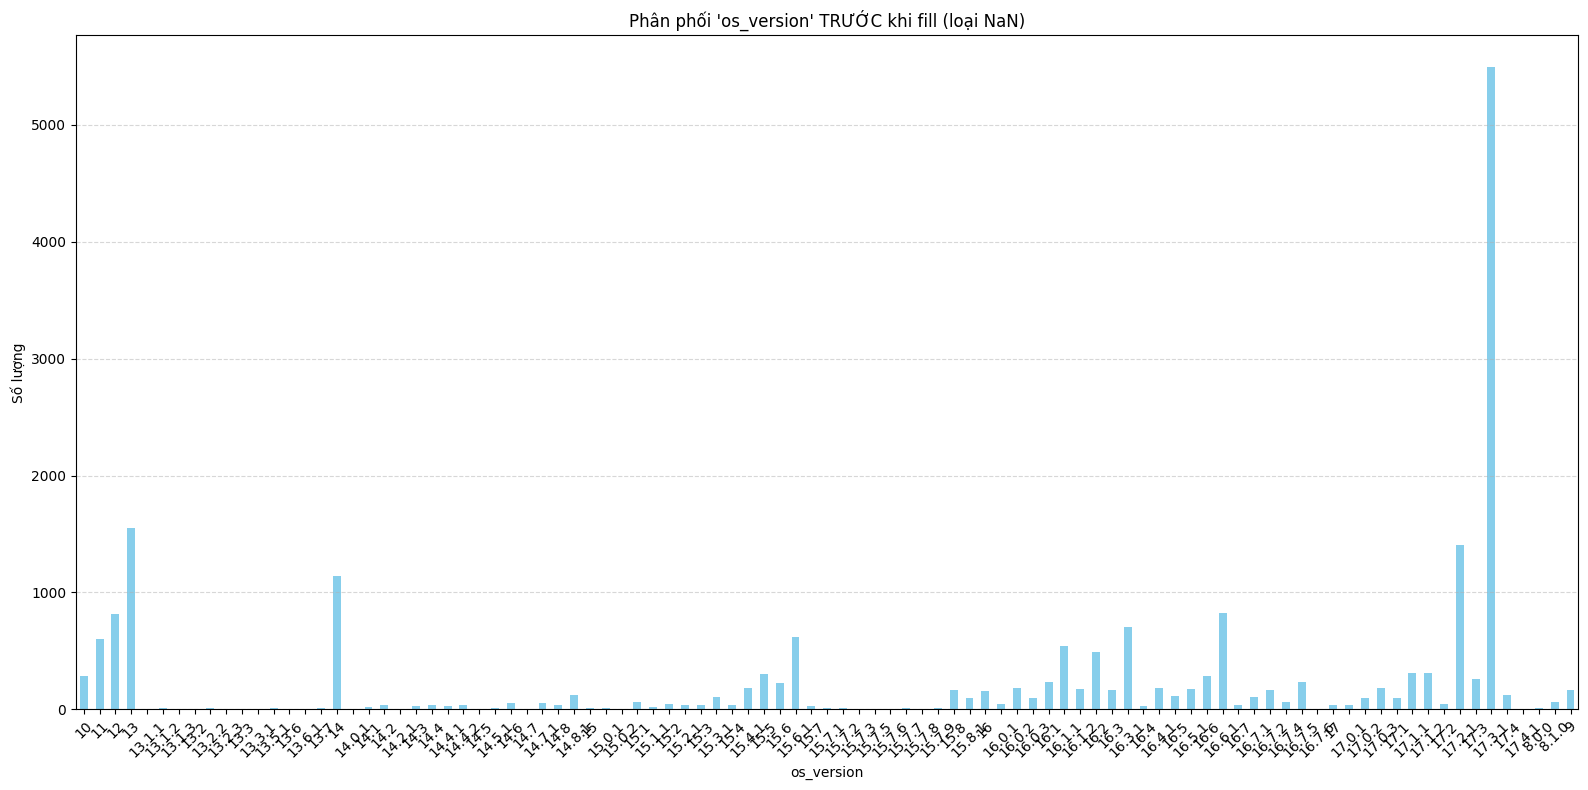

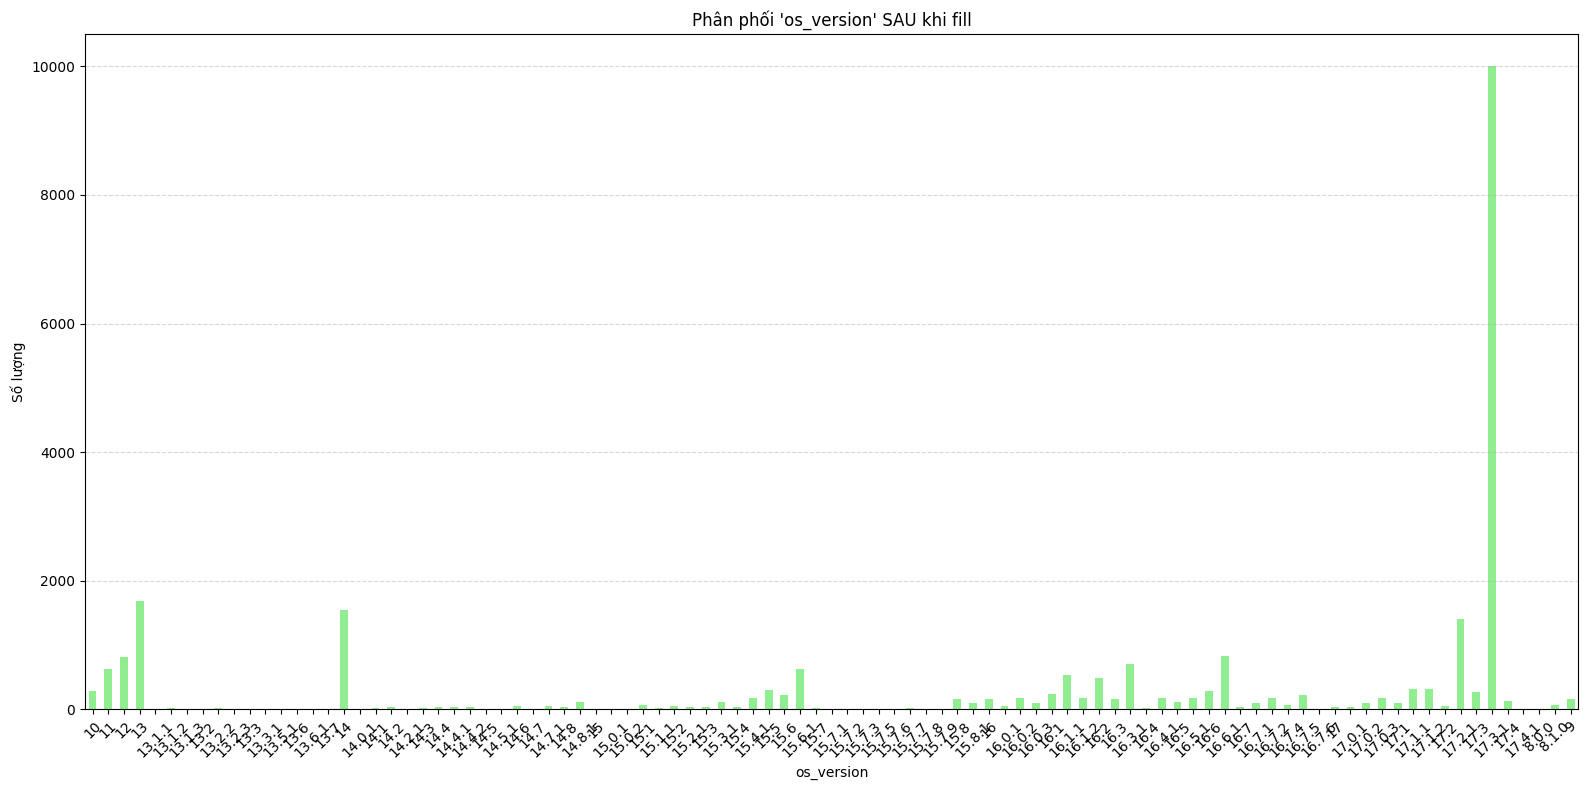

In [39]:
import matplotlib.pyplot as plt

cols_to_plot = ['device_system_name', 'os_version']

for col in cols_to_plot:
    # Biểu đồ cột trước khi fill
    before_dist = df[col].dropna().value_counts().sort_index()
    plt.figure(figsize=(16, 8))
    before_dist.plot(kind='bar', color='skyblue')
    plt.title(f"Phân phối '{col}' TRƯỚC khi fill (loại NaN)")
    plt.xlabel(col)
    plt.ylabel("Số lượng")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Biểu đồ cột sau khi fill
    after_dist = df_context[col].value_counts(dropna=False).sort_index()
    plt.figure(figsize=(16, 8))
    after_dist.plot(kind='bar', color='lightgreen')
    plt.title(f"Phân phối '{col}' SAU khi fill")
    plt.xlabel(col)
    plt.ylabel("Số lượng")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


## **5. Định dạng lại các cột cần thiết**

In [40]:
df_cleaned = df_context.copy()
df_cleaned['begin_time'] = pd.to_datetime(df_cleaned['begin_time'], errors='coerce', dayfirst=True)
df_cleaned['close_time'] = pd.to_datetime(df_cleaned['close_time'], errors='coerce', dayfirst=True)

df_cleaned.dtypes

,0
begin_time,datetime64[ns]
close_time,datetime64[ns]
status,object
gender,object
birth_year,float64
phone_type,object
device_system_name,object
os_version,object
rejected_reason,object
stop_point,object


In [41]:
df_context.head(25)

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,01/03/2024 10:32,01/03/2024 10:32,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0
1,01/03/2024 19:38,01/03/2024 19:41,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0
2,01/03/2024 10:25,01/03/2024 10:25,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
3,01/03/2024 16:16,01/03/2024 16:17,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
4,04/03/2024 13:30,04/03/2024 13:31,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
5,04/03/2024 13:31,04/03/2024 13:31,pending,F,1998.0,Apple,iOS,15.6,NaN,data-privacy-rejected,1
6,12/03/2024 14:10,12/03/2024 14:10,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
7,12/03/2024 17:01,12/03/2024 17:01,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
8,13/03/2024 11:33,13/03/2024 11:34,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
9,29/02/2024 15:06,29/02/2024 15:06,pending,F,1998.0,Apple,iOS,15.6,NaN,otp-failed,1


In [42]:
df_cleaned.head(25)

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id
0,2024-03-01 10:32:00,2024-03-01 10:32:00,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0
1,2024-03-01 19:38:00,2024-03-01 19:41:00,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0
2,2024-03-01 10:25:00,2024-03-01 10:25:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
3,2024-03-01 16:16:00,2024-03-01 16:17:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
4,2024-03-04 13:30:00,2024-03-04 13:31:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
5,2024-03-04 13:31:00,2024-03-04 13:31:00,pending,F,1998.0,Apple,iOS,15.6,NaN,data-privacy-rejected,1
6,2024-03-12 14:10:00,2024-03-12 14:10:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
7,2024-03-12 17:01:00,2024-03-12 17:01:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
8,2024-03-13 11:33:00,2024-03-13 11:34:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1
9,2024-02-29 15:06:00,2024-02-29 15:06:00,pending,F,1998.0,Apple,iOS,15.6,NaN,otp-failed,1


In [43]:
# Check remaining missing values after imputation.

df_cleaned.isna().sum()

,0
begin_time,0
close_time,0
status,0
gender,0
birth_year,0
phone_type,0
device_system_name,0
os_version,0
rejected_reason,22679
stop_point,0


In [44]:
df.begin_time.value_counts()

,count
begin_time,
29/02/2024 13:48,172
29/02/2024 13:43,165
29/02/2024 13:44,161
29/02/2024 13:45,157
29/02/2024 13:47,155
...,...
31/01/2024 14:08,1
31/01/2024 15:13,1
31/01/2024 15:16,1


## **6. Tạo thêm các cột cần thiết**

In [45]:


# Tạo cột duration (đơn vị: phút)
df_cleaned['duration'] = (df_cleaned['close_time'] - df_cleaned['begin_time']).dt.total_seconds() / 60

# Tạo cột age
df_cleaned['age'] = 2024 - df_cleaned['birth_year']


In [46]:
import pandas as pd

# Chuyển cột begin_time sang kiểu datetime nếu chưa
df_cleaned['begin_time'] = pd.to_datetime(df_cleaned['begin_time'])

# Tạo cột weekday (thứ trong tuần)
df_cleaned['weekday'] = df_cleaned['begin_time'].dt.day_name()

import pandas as pd
import matplotlib.pyplot as plt

# Chuyển đổi cột thời gian
df_cleaned['begin_time'] = pd.to_datetime(df_cleaned['begin_time'])

# Phân loại theo buổi
def classify_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    else:
        return 'Evening'

df_cleaned['time_period'] = df_cleaned['begin_time'].dt.hour.apply(classify_period)

def categorize_generation(age):
    if age >= 60:
        return 'Boomers'
    elif 44 <= age < 60:
        return 'Gen X'
    elif 28 <= age < 44:
        return 'Gen Y (Millennials)'
    elif age < 28:
        return 'Gen Z'
    else:
        return 'Unknown'

df_cleaned['generation'] = df_cleaned['age'].apply(categorize_generation)

## **7. Dữ liệu đã Cleaned, xuất ra xlsx**

In [47]:
df_cleaned.head()

,begin_time,close_time,status,gender,birth_year,phone_type,device_system_name,os_version,rejected_reason,stop_point,customer_id,duration,age,weekday,time_period,generation
0,2024-03-01 10:32:00,2024-03-01 10:32:00,pending,F,1993.0,Apple,iOS,16.1.1,NaN,otp-failed,0,0.0,31.0,Friday,Morning,Gen Y (Millennials)
1,2024-03-01 19:38:00,2024-03-01 19:41:00,succeed,F,1993.0,Apple,iOS,16.1.1,NaN,account-creation,0,3.0,31.0,Friday,Evening,Gen Y (Millennials)
2,2024-03-01 10:25:00,2024-03-01 10:25:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,0.0,26.0,Friday,Morning,Gen Z
3,2024-03-01 16:16:00,2024-03-01 16:17:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Friday,Afternoon,Gen Z
4,2024-03-04 13:30:00,2024-03-04 13:31:00,fail,F,1998.0,Apple,iOS,15.6,document-ocr-failed,ocr-failed,1,1.0,26.0,Monday,Afternoon,Gen Z


In [48]:
# Verify null counts in the cleaned dataset.

df_cleaned.isnull().sum()

,0
begin_time,0
close_time,0
status,0
gender,0
birth_year,0
phone_type,0
device_system_name,0
os_version,0
rejected_reason,22679
stop_point,0


In [49]:
# Export step removed from the public notebook.
